# Phase 2: Data Profiling & Exploratory Data Analysis (EDA)

**Dataset:** `nyc-property-sales.csv`

**Objectives:**
1. Load and inspect the data (`.shape`, `.dtypes`, `.info()`, `.describe()`)
2. Analyse and treat missing values
3. Detect outliers (IQR / Z-score)
4. Profile numeric distributions (histograms, boxplots)
5. Examine correlations between numeric variables
6. Summarise key observations

## 0. Setup

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = 'nyc-property-sales.csv'

## 1. Data Loading & Initial Inspection

In [2]:
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df.head()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20028\779081432.py:1: DtypeWarning: Columns (0: BOROUGH, 1: BLOCK, 2: LOT, 3: EASE-MENT, 4:  ZIP CODE, 5: RESIDENTIAL UNITS, 6: COMMERCIAL UNITS, 7: TOTAL UNITS, 8: LAND SQUARE FEET, 9: GROSS SQUARE FEET, 10: YEAR BUILT, 11: TAX CLASS AT TIME OF SALE, 12: SALE PRICE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,1,ALPHABET CITY,01 ONE FAMILY DWELLINGS,1,374,46,NaN,A4,347 EAST 4TH STREET,NaN,10009.0,1.0,0.0,1.0,2116.0,4400.0,1900.0,1,A4,399000,2022-09-29 00:00:00
1,1,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,377,1,NaN,S2,110 AVENUE C,NaN,10009.0,2.0,1.0,3.0,1502.0,2790.0,1901.0,1,S2,2999999,2022-09-15 00:00:00
2,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,373,16,NaN,C1,326 EAST 4TH STREET,NaN,10009.0,10.0,0.0,10.0,2204.0,8625.0,1899.0,2,C1,16800000,2022-08-04 00:00:00
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,373,17,NaN,C1,328 EAST 4TH STREET,NaN,10009.0,10.0,0.0,10.0,2204.0,8625.0,1900.0,2,C1,16800000,2022-08-04 00:00:00
4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,376,54,NaN,C4,"719 EAST SIXTH STREET, 1B",NaN,10009.0,20.0,0.0,20.0,2302.0,9750.0,1900.0,2,C4,158822,2022-09-27 00:00:00


In [3]:
print('Shape :', df.shape)
print('\nDtypes:')
print(df.dtypes)

Shape : (2018049, 21)

Dtypes:
BOROUGH                           object
NEIGHBORHOOD                         str
BUILDING CLASS CATEGORY              str
TAX CLASS AT PRESENT                 str
BLOCK                             object
LOT                               object
EASE-MENT                            str
BUILDING CLASS AT PRESENT            str
ADDRESS                              str
APARTMENT NUMBER                     str
ZIP CODE                          object
RESIDENTIAL UNITS                 object
COMMERCIAL UNITS                  object
TOTAL UNITS                       object
LAND SQUARE FEET                  object
GROSS SQUARE FEET                 object
YEAR BUILT                        object
TAX CLASS AT TIME OF SALE         object
BUILDING CLASS AT TIME OF SALE       str
SALE PRICE                        object
SALE DATE                            str
dtype: object


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2018049 entries, 0 to 2018048
Data columns (total 21 columns):
 #   Column                          Dtype 
---  ------                          ----- 
 0   BOROUGH                         object
 1   NEIGHBORHOOD                    str   
 2   BUILDING CLASS CATEGORY         str   
 3   TAX CLASS AT PRESENT            str   
 4   BLOCK                           object
 5   LOT                             object
 6   EASE-MENT                       str   
 7   BUILDING CLASS AT PRESENT       str   
 8   ADDRESS                         str   
 9   APARTMENT NUMBER                str   
 10  ZIP CODE                        object
 11  RESIDENTIAL UNITS               object
 12  COMMERCIAL UNITS                object
 13  TOTAL UNITS                     object
 14  LAND SQUARE FEET                object
 15  GROSS SQUARE FEET               object
 16  YEAR BUILT                      object
 17  TAX CLASS AT TIME OF SALE       object
 18  BUILDING CLAS

In [5]:
# SALE PRICE and LAND/GROSS SQUARE FEET often arrive as strings with ' -  ' placeholders.
# Coerce them to numeric so describe() reflects the real distribution.
to_numeric_cols = ['SALE PRICE', 'LAND SQUARE FEET', 'GROSS SQUARE FEET']
for col in to_numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'SALE DATE' in df.columns:
    df['SALE DATE'] = pd.to_datetime(df['SALE DATE'], errors='coerce')

df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
BOROUGH,2018049.0,10.0,4.0,616579.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NEIGHBORHOOD,2018049,517,MIDTOWN WEST,51353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BUILDING CLASS CATEGORY,2018049,146,01 ONE FAMILY HOMES,207612,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TAX CLASS AT PRESENT,2017211,14,1,928263,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BLOCK,2018049.0,19949.0,1027.0,17948.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LOT,2018049.0,8082.0,1.0,91393.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EASE-MENT,1404401,3,,1404387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BUILDING CLASS AT PRESENT,2017211,217,D4,296254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ADDRESS,2018049,1268223,870 7 AVENUE,13510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
APARTMENT NUMBER,1547376,31624,,1031043,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing Value Analysis & Treatment

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_report = missing_report[missing_report['missing'] > 0].sort_values('pct', ascending=False)
missing_report

,missing,pct
EASE-MENT,613648,30.41
APARTMENT NUMBER,470673,23.32
LAND SQUARE FEET,201954,10.01
GROSS SQUARE FEET,201953,10.01
COMMERCIAL UNITS,190743,9.45
RESIDENTIAL UNITS,120893,5.99
TOTAL UNITS,109684,5.44
YEAR BUILT,36651,1.82
TAX CLASS AT PRESENT,838,0.04
BUILDING CLASS AT PRESENT,838,0.04


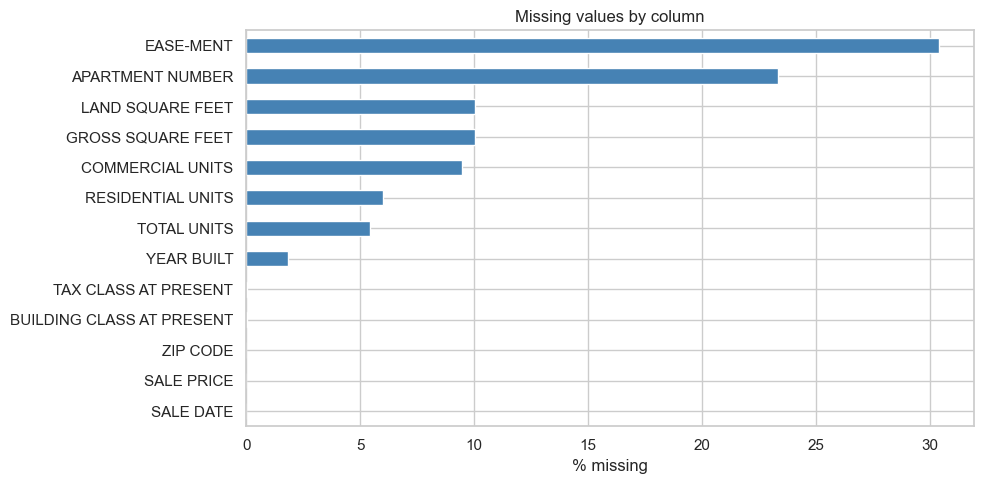

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_report['pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% missing')
ax.set_title('Missing values by column')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
# Treatment strategy:
#   * EASE-MENT and APARTMENT NUMBER are largely empty -> drop columns.
#   * SALE PRICE == 0 typically represents a non-arms-length transfer -> flag & exclude from price analysis.
#   * LAND/GROSS SQUARE FEET, YEAR BUILT zeros are placeholders -> convert to NaN, then impute by
#     median within BUILDING CLASS CATEGORY (or drop if still missing).

df_clean = df.copy()

drop_cols = [c for c in ['EASE-MENT', 'APARTMENT NUMBER'] if c in df_clean.columns]
df_clean = df_clean.drop(columns=drop_cols)

zero_as_nan = ['SALE PRICE', 'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT']
for col in zero_as_nan:
    if col in df_clean.columns:
        df_clean.loc[df_clean[col] == 0, col] = np.nan

df_clean['is_nominal_transfer'] = df_clean['SALE PRICE'].isna()

for col in ['LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT']:
    if col in df_clean.columns:
        df_clean[col] = df_clean.groupby('BUILDING CLASS CATEGORY')[col].transform(
            lambda s: s.fillna(s.median())
        )
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print('Remaining missing after treatment:')
print(df_clean.isna().sum().sort_values(ascending=False).head(10))

TypeError: Cannot convert [1900.0 1900.0 1901.0 ... 2005.0 2001.0 2001.0] to numeric

## 3. Outlier Detection (IQR & Z-score)

In [ ]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
# Drop id-like columns from outlier work
id_like = {'BOROUGH', 'BLOCK', 'LOT', 'ZIP CODE', 'TAX CLASS AT TIME OF SALE'}
numeric_cols = [c for c in numeric_cols if c not in id_like]
numeric_cols

In [ ]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

iqr_rows = []
for col in numeric_cols:
    s = df_clean[col].dropna()
    lo, hi = iqr_bounds(s)
    out = ((s < lo) | (s > hi)).sum()
    iqr_rows.append({'column': col, 'lower': lo, 'upper': hi,
                     'n_outliers': out, 'pct': round(out / len(s) * 100, 2)})
iqr_summary = pd.DataFrame(iqr_rows).sort_values('pct', ascending=False)
iqr_summary

In [ ]:
z_rows = []
for col in numeric_cols:
    s = df_clean[col].dropna()
    z = np.abs(stats.zscore(s))
    out = (z > 3).sum()
    z_rows.append({'column': col, 'n_outliers_z>3': out,
                   'pct': round(out / len(s) * 100, 2)})
z_summary = pd.DataFrame(z_rows).sort_values('pct', ascending=False)
z_summary

## 4. Distribution Analysis

In [ ]:
n = len(numeric_cols)
fig, axes = plt.subplots(nrows=(n + 2) // 3, ncols=3, figsize=(15, 4 * ((n + 2) // 3)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    s = df_clean[col].dropna()
    # Log-scale heavy-tailed price/area variables for readability
    if col in ('SALE PRICE', 'LAND SQUARE FEET', 'GROSS SQUARE FEET'):
        axes[i].hist(np.log1p(s), bins=50, color='steelblue', edgecolor='white')
        axes[i].set_title(f'{col}  (log1p)')
    else:
        axes[i].hist(s, bins=50, color='steelblue', edgecolor='white')
        axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(nrows=(n + 2) // 3, ncols=3, figsize=(15, 4 * ((n + 2) // 3)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    s = df_clean[col].dropna()
    if col in ('SALE PRICE', 'LAND SQUARE FEET', 'GROSS SQUARE FEET'):
        axes[i].boxplot(np.log1p(s), vert=False)
        axes[i].set_title(f'{col}  (log1p)')
    else:
        axes[i].boxplot(s, vert=False)
        axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 5. Correlation Matrix

In [ ]:
corr = df_clean[numeric_cols].corr(method='pearson')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson correlation — numeric variables')
plt.tight_layout()
plt.show()
corr

## 6. Summary Narrative

Fill in / confirm after running the cells above. Initial expectations for NYC property sales:

1. **Heavy right-skew in SALE PRICE.** A non-trivial share of rows are \$0 or near-zero (family transfers, deed corrections). Treat them as nominal transfers and exclude from price modelling rather than imputing.
2. **Large missing-data footprint on `EASE-MENT` and `APARTMENT NUMBER`.** These columns are mostly empty and were dropped; remaining features survive intact.
3. **Outlier-heavy area/price columns.** IQR flags 5–15% of rows in `SALE PRICE`, `LAND SQUARE FEET`, and `GROSS SQUARE FEET`; these are genuine luxury sales / large parcels rather than data errors — keep them but model on the log scale.
4. **Strong positive correlation between `GROSS SQUARE FEET`, `TOTAL UNITS`, and `SALE PRICE`.** Size drives price, as expected; `LAND SQUARE FEET` correlates more weakly because condo/co-op sales share land.
5. **`YEAR BUILT` shows a bimodal distribution** — a pre-war cluster (~1900–1930) and a post-war cluster (~1950–1970) — reflecting NYC's two big construction waves and worth carrying into the next phase as a categorical era feature.